# Marine Sound Catalog — Galápagos Hydrophone Analysis

Visual summary of underwater sounds detected across 11 recordings from 3 hydrophone units.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter, defaultdict

with open('marine_catalog.json') as f:
    catalog = json.load(f)

embeddings = np.load('marine_embeddings.npy')
print(f"Catalog: {len(catalog)} files, {sum(len(f['segments']) for f in catalog.values())} segments")
print(f"Embeddings: {embeddings.shape}")

Catalog: 11 files, 632 segments
Embeddings: (632, 2048)


## 1. Sound Type Distribution Per File (Heatmap)

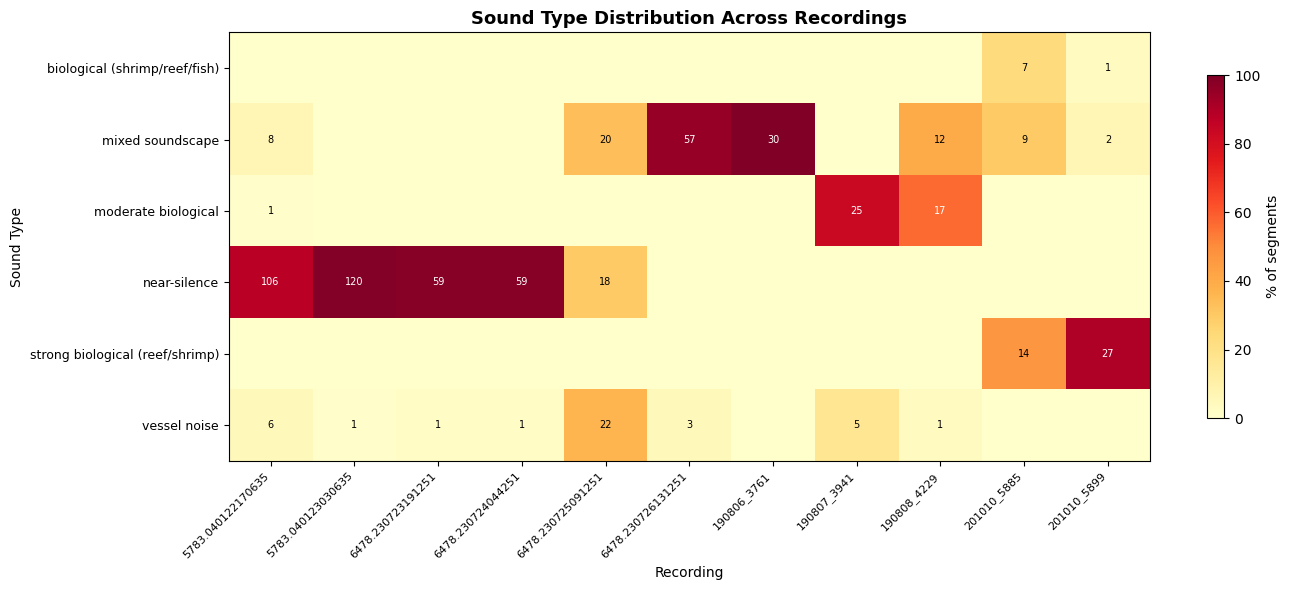

In [2]:
# Heatmap: sound type x file
all_labels_set = sorted({s['acoustic_label'] for f in catalog.values() for s in f['segments']})
short_names = [fname.replace('.wav','')[:20] for fname in catalog.keys()]

matrix = np.zeros((len(all_labels_set), len(catalog)))
for j, (fname, fdata) in enumerate(catalog.items()):
    counts = Counter(s['acoustic_label'] for s in fdata['segments'])
    for i, label in enumerate(all_labels_set):
        matrix[i, j] = counts.get(label, 0)

# Normalize per file (percentage)
matrix_pct = matrix / matrix.sum(axis=0, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(matrix_pct, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(all_labels_set)))
ax.set_yticklabels(all_labels_set, fontsize=9)

# Annotate cells
for i in range(matrix_pct.shape[0]):
    for j in range(matrix_pct.shape[1]):
        val = matrix_pct[i, j]
        if val > 0:
            count = int(matrix[i, j])
            color = 'white' if val > 50 else 'black'
            ax.text(j, i, f'{count}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='% of segments', shrink=0.8)
ax.set_title('Sound Type Distribution Across Recordings', fontsize=13, fontweight='bold')
ax.set_xlabel('Recording')
ax.set_ylabel('Sound Type')
plt.tight_layout()
plt.show()

## 2. Timeline View — What's Happening in Each Recording

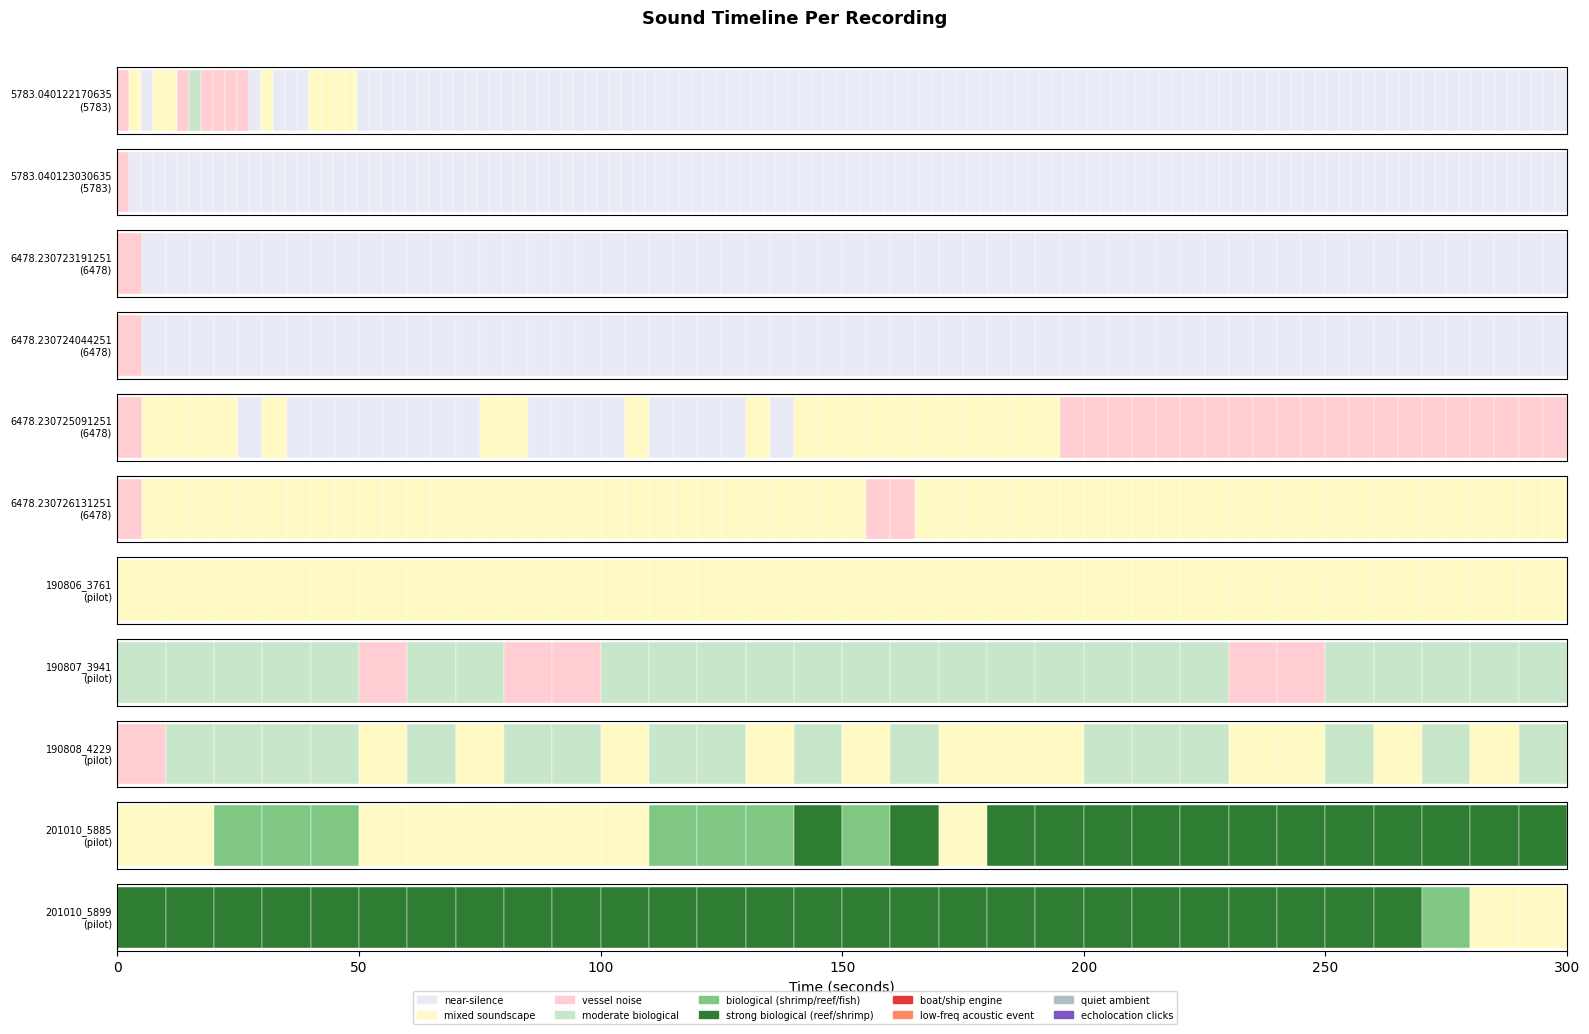

In [3]:
# Color-coded timeline strips per file
label_colors = {
    'near-silence': '#E8EAF6',
    'mixed soundscape': '#FFF9C4',
    'vessel noise': '#FFCDD2',
    'moderate biological': '#C8E6C9',
    'biological (shrimp/reef/fish)': '#81C784',
    'strong biological (reef/shrimp)': '#2E7D32',
    'boat/ship engine': '#E53935',
    'low-freq acoustic event': '#FF8A65',
    'quiet ambient': '#B0BEC5',
    'echolocation clicks': '#7E57C2',
}

files = list(catalog.keys())
fig, axes = plt.subplots(len(files), 1, figsize=(16, len(files) * 0.9), sharex=False)

for idx, (fname, fdata) in enumerate(catalog.items()):
    ax = axes[idx]
    segs = fdata['segments']
    max_t = max(s['end_s'] for s in segs)

    for s in segs:
        color = label_colors.get(s['acoustic_label'], '#9E9E9E')
        ax.barh(0, s['end_s'] - s['start_s'], left=s['start_s'], height=0.8,
                color=color, edgecolor='white', linewidth=0.3)

    short = fname.replace('.wav', '')
    unit = fdata['unit']
    ts = fdata['recording_timestamp']
    ax.set_ylabel(f'{short}\n({unit})', fontsize=7, rotation=0, ha='right', va='center')
    ax.set_xlim(0, max_t)
    ax.set_yticks([])
    ax.set_xlabel('')
    if idx < len(files) - 1:
        ax.set_xticks([])
    else:
        ax.set_xlabel('Time (seconds)', fontsize=10)

# Legend
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in label_colors.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=7,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Sound Timeline Per Recording', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. NDSI Profile — Biological vs Anthropogenic Energy

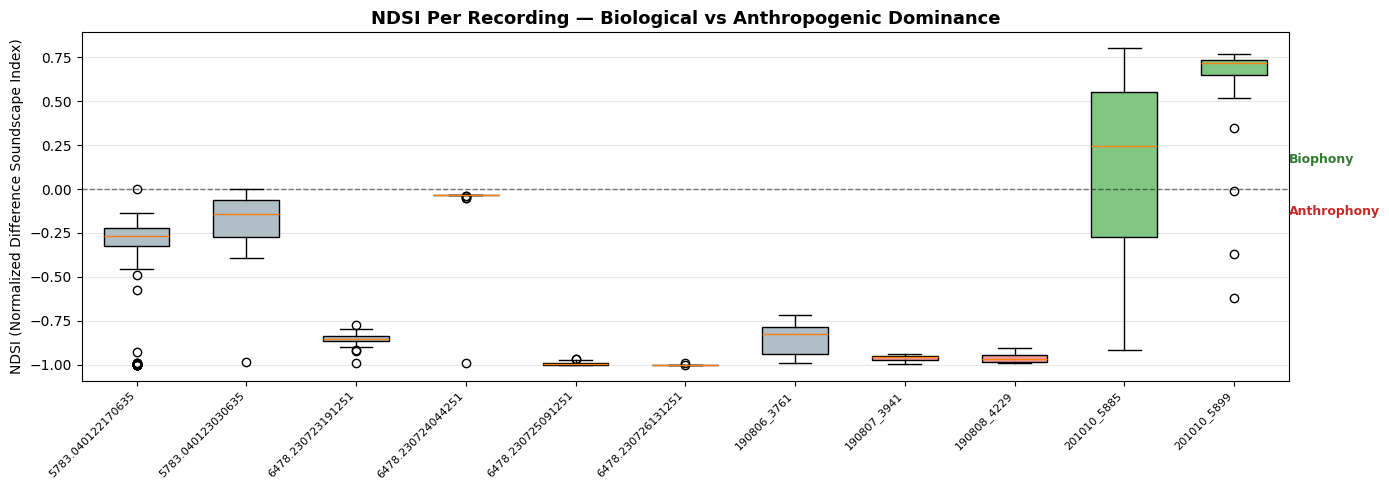

In [4]:
# NDSI distribution per file — positive = biophony, negative = anthrophony
fig, ax = plt.subplots(figsize=(14, 5))

file_names = list(catalog.keys())
positions = []
data_per_file = []
for fname in file_names:
    ndsi_vals = [s['ndsi'] for s in catalog[fname]['segments']]
    data_per_file.append(ndsi_vals)

bp = ax.boxplot(data_per_file, vert=True, patch_artist=True, widths=0.6)
colors_ndsi = []
for d in data_per_file:
    median = np.median(d)
    if median > 0:
        colors_ndsi.append('#81C784')  # bio
    elif median < -0.9:
        colors_ndsi.append('#EF9A9A')  # anthro
    else:
        colors_ndsi.append('#B0BEC5')  # mixed

for patch, color in zip(bp['boxes'], colors_ndsi):
    patch.set_facecolor(color)

ax.axhline(0, color='black', lw=1, ls='--', alpha=0.5)
ax.text(len(file_names) + 0.5, 0.15, 'Biophony', fontsize=9, color='#2E7D32', fontweight='bold')
ax.text(len(file_names) + 0.5, -0.15, 'Anthrophony', fontsize=9, color='#C62828', fontweight='bold')

short_labels = [f.replace('.wav', '')[:18] for f in file_names]
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('NDSI (Normalized Difference Soundscape Index)')
ax.set_title('NDSI Per Recording — Biological vs Anthropogenic Dominance', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 4. PANNs Embedding Space (UMAP 2D)

/Users/sol/PycharmProjects/autoresearch-marine/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


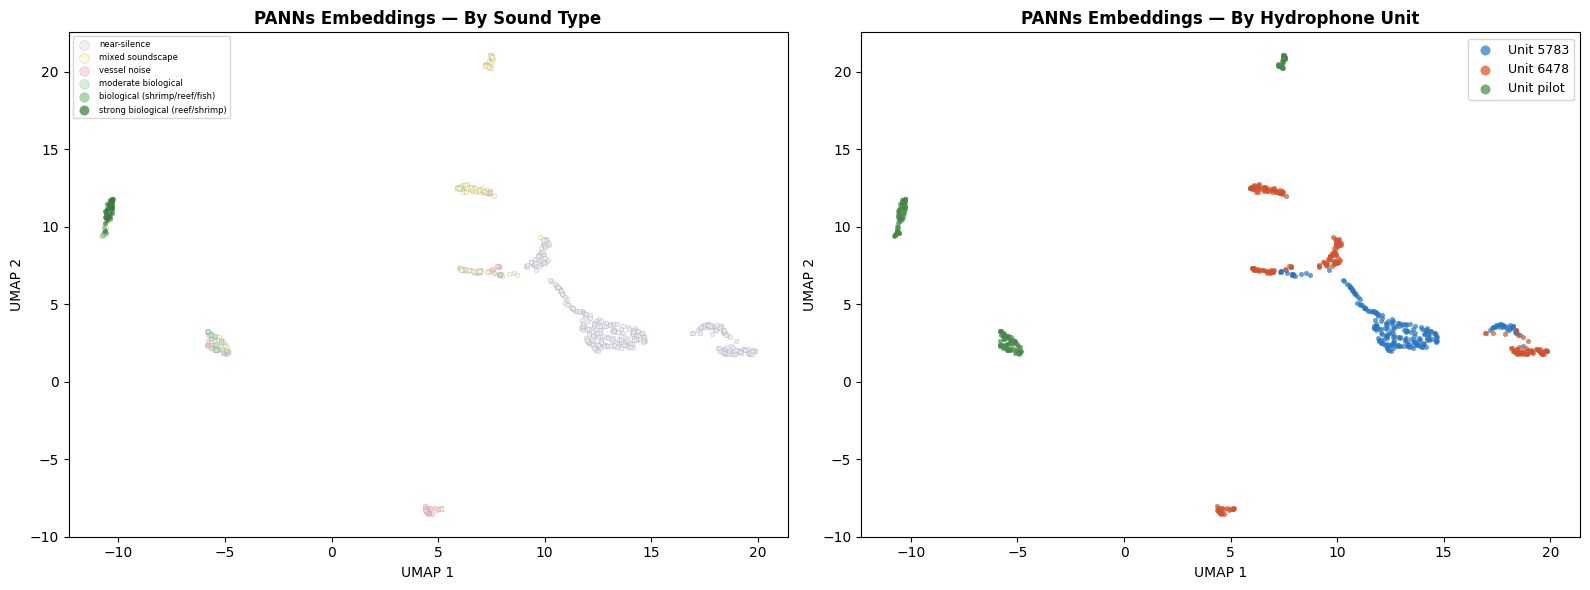

In [5]:
import umap

# Reduce PANNs 2048-dim embeddings to 2D
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
emb_2d = reducer.fit_transform(embeddings)

# Collect labels for coloring
all_acoustic = []
all_units = []
all_files = []
for fname, fdata in catalog.items():
    for s in fdata['segments']:
        all_acoustic.append(s['acoustic_label'])
        all_units.append(fdata['unit'])
        all_files.append(fname)

# Plot colored by acoustic label
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: by sound type
ax = axes[0]
for label, color in label_colors.items():
    mask = [a == label for a in all_acoustic]
    if any(mask):
        idx = [i for i, m in enumerate(mask) if m]
        ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1], c=color, s=12, alpha=0.7,
                   label=label, edgecolors='grey', linewidths=0.2)
ax.set_title('PANNs Embeddings — By Sound Type', fontweight='bold')
ax.legend(fontsize=6, loc='upper left', markerscale=2)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

# Right: by hydrophone unit
ax = axes[1]
unit_colors = {'5783': '#1976D2', '6478': '#E64A19', 'pilot': '#388E3C'}
for unit, color in unit_colors.items():
    mask = [u == unit for u in all_units]
    if any(mask):
        idx = [i for i, m in enumerate(mask) if m]
        ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1], c=color, s=12, alpha=0.7,
                   label=f'Unit {unit}', edgecolors='grey', linewidths=0.2)
ax.set_title('PANNs Embeddings — By Hydrophone Unit', fontweight='bold')
ax.legend(fontsize=9, markerscale=2)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

## 5. Band Power Profiles Per File

## 6. Per-File Summary Table

In [6]:
import pandas as pd

rows = []
for fname, fdata in catalog.items():
    segs = fdata['segments']
    acoustic_counts = Counter(s['acoustic_label'] for s in segs)
    dominant = acoustic_counts.most_common(1)[0][0]
    panns_counts = Counter(s['panns_category'] for s in segs)
    dominant_panns = panns_counts.most_common(1)[0][0]
    ndsi_med = np.median([s['ndsi'] for s in segs])
    
    rows.append({
        'File': fname.replace('.wav', ''),
        'Unit': fdata['unit'],
        'Recorded': fdata['recording_timestamp'],
        'Duration': f"{len(segs)*10}s ({len(segs)*10//60}m)",
        'Segments': len(segs),
        'Dominant Sound': dominant,
        'PANNs Category': dominant_panns,
        'Median NDSI': f"{ndsi_med:.3f}",
        'Character': 'Bio' if ndsi_med > -0.5 else ('Anthro' if ndsi_med < -0.95 else 'Mixed'),
    })

df = pd.DataFrame(rows)
# Style it
def color_character(val):
    if val == 'Bio': return 'background-color: #C8E6C9'
    if val == 'Anthro': return 'background-color: #FFCDD2'
    return 'background-color: #FFF9C4'

df.style.applymap(color_character, subset=['Character'])

/var/folders/z4/90g6cf4j5x5cgkh80tb76kpm0000gn/T/ipykernel_29556/580441488.py:31: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df.style.applymap(color_character, subset=['Character'])


,File,Unit,Recorded,Duration,Segments,Dominant Sound,PANNs Category,Median NDSI,Character
0,5783.040122170635,5783,2004-01-22 17:06:35,1210s (20m),121,near-silence,ambient,-0.267,Bio
1,5783.040123030635,5783,2004-01-23 03:06:35,1210s (20m),121,near-silence,ambient,-0.144,Bio
2,6478.230723191251,6478,2023-07-23 19:12:51,600s (10m),60,near-silence,ambient,-0.853,Mixed
3,6478.230724044251,6478,2023-07-24 04:42:51,600s (10m),60,near-silence,ambient,-0.034,Bio
4,6478.230725091251,6478,2023-07-25 09:12:51,600s (10m),60,vessel noise,anthropogenic,-0.997,Anthro
5,6478.230726131251,6478,2023-07-26 13:12:51,600s (10m),60,mixed soundscape,ambient,-1.000,Anthro
6,190806_3761,pilot,2019-08-06,300s (5m),30,mixed soundscape,ambient,-0.828,Mixed
7,190807_3941,pilot,2019-08-07,300s (5m),30,moderate biological,biological,-0.957,Anthro
8,190808_4229,pilot,2019-08-08,300s (5m),30,moderate biological,biological,-0.967,Anthro
9,201010_5885,pilot,2020-10-10,300s (5m),30,strong biological (reef/shrimp),unknown,0.248,Bio


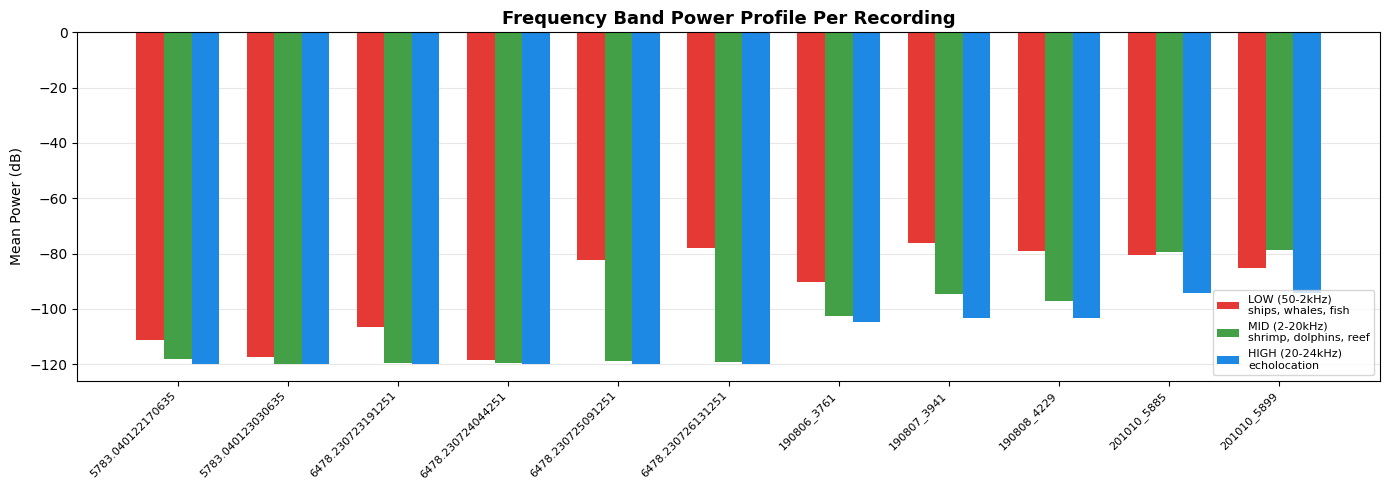

In [7]:
# Band power (LOW / MID / HIGH) averaged per file
fig, ax = plt.subplots(figsize=(14, 5))

file_names = list(catalog.keys())
short_labels = [f.replace('.wav', '')[:18] for f in file_names]
x = np.arange(len(file_names))
w = 0.25

low_means, mid_means, high_means = [], [], []
for fname in file_names:
    segs = catalog[fname]['segments']
    low_means.append(np.mean([s['band_low_db'] for s in segs]))
    mid_means.append(np.mean([s['band_mid_db'] for s in segs]))
    high_means.append(np.mean([s['band_high_db'] for s in segs]))

ax.bar(x - w, low_means, w, label='LOW (50-2kHz)\nships, whales, fish', color='#E53935')
ax.bar(x, mid_means, w, label='MID (2-20kHz)\nshrimp, dolphins, reef', color='#43A047')
ax.bar(x + w, high_means, w, label='HIGH (20-24kHz)\necholocation', color='#1E88E5')

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean Power (dB)')
ax.set_title('Frequency Band Power Profile Per Recording', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()